# Deep Soil Exponential Hydraulic Conductivity Profiles

This notebook loads `deep_properties()` from `parameters_krycklan.py` to get the soil type names and `deep_id` values, then assigns exponential-profile parameters explicitly in the notebook and plots

$$K(z) = (K_{max} - K_{min}) \, e^{-fz} + K_{min}$$

for each soil type down to its assigned maximum depth.

## 1. Import Libraries and Set Paths

In [1]:
import pathlib
import sys
import importlib.util

import numpy as np
import matplotlib.pyplot as plt

project_root = pathlib.Path.cwd().parent
scripts_folder = project_root / 'scripts'

sys.path.insert(0, str(project_root))

print(f"Project root: {project_root}")
print(f"Scripts folder: {scripts_folder}")

Project root: /Users/jpnousu/Models/SpaFHy_v2.0
Scripts folder: /Users/jpnousu/Models/SpaFHy_v2.0/scripts


## 2. Load `deep_properties()` from `parameters_krycklan.py`

In [2]:
spec = importlib.util.spec_from_file_location(
    'parameters_krycklan',
    project_root / 'parameters_krycklan.py'
)
param_module = importlib.util.module_from_spec(spec)
spec.loader.exec_module(param_module)

deep_properties = param_module.deep_properties()

print(f"Number of soil types: {len(deep_properties)}")
print(f"Soil types: {list(deep_properties.keys())}")

Number of soil types: 11
Soil types: ['Postglacial_sand', 'Glaciofluvial_sediment', 'Peat', 'Postglacial_sand_gravel', 'Clay_silt', 'Washed_sediment_gravel_boulders', 'Water', 'Moraine', 'Fill', 'Bedrock', 'Fluvial_sediment_sand']


## 3. Define Exponential Profile Parameters

$$K(z) = (K_{max} - K_{min}) \, e^{-fz} + K_{min}$$

where $K_{max}$ is the assigned surface hydraulic conductivity [m/s], $K_{min}$ is the assigned background deep conductivity [m/s], $z$ is depth [m] positive downward, and $f$ is the decay coefficient [m$^{-1}$].

In this notebook, $K_{max}$ and maximum depth are set explicitly as parameters rather than read from `deep_properties()`.

In [3]:
# Only soil names and deep_id values are taken from deep_properties.
# Kmax, Kmin, f, and max_depth are assigned explicitly here.

kmax_values = {
    'Postglacial_sand':                5e-5,
    'Glaciofluvial_sediment':          5e-5,
    'Peat':                            3e-4,
    'Postglacial_sand_gravel':         3e-5,
    'Clay_silt':                       1e-8,
    'Washed_sediment_gravel_boulders': 5e-5,
    'Water':                           1e-8,
    'Moraine':                         1e-5,
    'Fill':                            1e-5,
    'Bedrock':                         1e-6,
    'Fluvial_sediment_sand':           5e-5,
}

kmin_values = {
    'Postglacial_sand':                1e-6,
    'Glaciofluvial_sediment':          1e-6,
    'Peat':                            1e-6,
    'Postglacial_sand_gravel':         1e-6,
    'Clay_silt':                       1e-9,
    'Washed_sediment_gravel_boulders': 1e-6,
    'Water':                           1e-9,
    'Moraine':                         1e-6,
    'Fill':                            1e-7,
    'Bedrock':                         1e-10,
    'Fluvial_sediment_sand':           1e-6,
}

f_values = {
    'Postglacial_sand':                1.0,
    'Glaciofluvial_sediment':          1.0,
    'Peat':                            2.0,
    'Postglacial_sand_gravel':         1.0,
    'Clay_silt':                       0.5,
    'Washed_sediment_gravel_boulders': 1.0,
    'Water':                           0.5,
    'Moraine':                         1.0,
    'Fill':                            1.0,
    'Bedrock':                         3.0,
    'Fluvial_sediment_sand':           1.5,
}

max_depth_values = {
    'Postglacial_sand':                10.0,
    'Glaciofluvial_sediment':          10.0,
    'Peat':                            10.0,
    'Postglacial_sand_gravel':         10.0,
    'Clay_silt':                       10.0,
    'Washed_sediment_gravel_boulders': 10.0,
    'Water':                           10.0,
    'Moraine':                         10.0,
    'Fill':                            10.0,
    'Bedrock':                         10.0,
    'Fluvial_sediment_sand':           10.0,
}

exp_params = {}
for soil_type, props in deep_properties.items():
    exp_params[soil_type] = {
        'deep_id': props['deep_id'],
        'Kmax': kmax_values[soil_type],
        'f': f_values[soil_type],
        'Kmin': kmin_values[soil_type],
        'max_depth': max_depth_values[soil_type],
    }

print(
    f"{'Soil type':42s}  {'deep_id':>7}  {'Kmax [m/s]':>12}  "
    f"{'Kmin [m/s]':>12}  {'f [m-1]':>8}  {'depth [m]':>10}"
)
print('-' * 104)
for soil_type, params in exp_params.items():
    print(
        f"  {soil_type:40s}  {params['deep_id']:7d}  {params['Kmax']:12.2e}  "
        f"{params['Kmin']:12.2e}  {params['f']:8.2f}  {params['max_depth']:10.2f}"
    )

Soil type                                   deep_id    Kmax [m/s]    Kmin [m/s]   f [m-1]   depth [m]
--------------------------------------------------------------------------------------------------------
  Postglacial_sand                                1      5.00e-05      1.00e-06      1.00       10.00
  Glaciofluvial_sediment                          2      5.00e-05      1.00e-06      1.00       10.00
  Peat                                            3      3.00e-04      1.00e-06      2.00       10.00
  Postglacial_sand_gravel                         4      3.00e-05      1.00e-06      1.00       10.00
  Clay_silt                                       5      1.00e-08      1.00e-09      0.50       10.00
  Washed_sediment_gravel_boulders                 6      5.00e-05      1.00e-06      1.00       10.00
  Water                                           7      1.00e-08      1.00e-09      0.50       10.00
  Moraine                                         8      1.00e-05      1.00e-06

## 4. Plot Exponential Profiles to Soil-Specific Depth

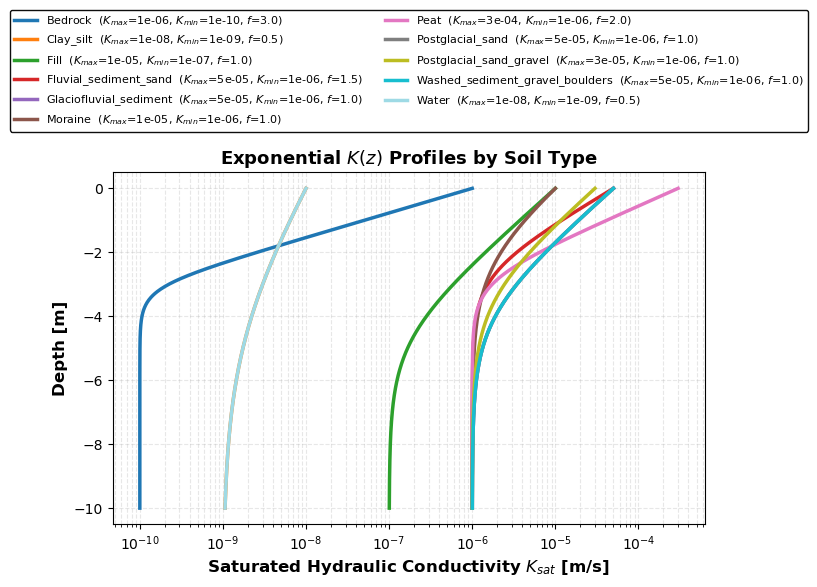

In [4]:
fig, ax = plt.subplots(figsize=(8, 7))

soil_types = sorted(exp_params.keys())
colors = plt.cm.tab20(np.linspace(0, 1, len(soil_types)))

for color, soil_type in zip(colors, soil_types):
    params = exp_params[soil_type]
    z = np.linspace(0, params['max_depth'], 500)
    K = (params['Kmax'] - params['Kmin']) * np.exp(-params['f'] * z) + params['Kmin']

    ax.plot(
        K,
        -z,
        linewidth=2.5,
        color=color,
        label=(
            f"{soil_type}  ($K_{{max}}$={params['Kmax']:.0e}, "
            f"$K_{{min}}$={params['Kmin']:.0e}, $f$={params['f']})"
        ),
    )

ax.set_xlabel('Saturated Hydraulic Conductivity $K_{sat}$ [m/s]', fontsize=12, fontweight='bold')
ax.set_ylabel('Depth [m]', fontsize=12, fontweight='bold')
ax.set_title('Exponential $K(z)$ Profiles by Soil Type', fontsize=13, fontweight='bold')
ax.set_xscale('log')
ax.grid(True, which='both', alpha=0.3, linestyle='--')
ax.legend(
    loc='lower center',
    bbox_to_anchor=(0.5, 1.1),
    ncol=2,
    fontsize=8,
    framealpha=0.95,
    edgecolor='black',
)

plt.tight_layout(rect=[0, 0, 1, 0.88])
plt.show()

In [5]:
def discretized_depths(max_depth):
    depth_breaks = []

    if max_depth > 0:
        upper = min(max_depth, 1.0)
        depth_breaks.extend(np.arange(0.1, upper + 1e-9, 0.1).tolist())
    if max_depth > 1.0:
        upper = min(max_depth, 2.0)
        depth_breaks.extend(np.arange(1.2, upper + 1e-9, 0.2).tolist())
    if max_depth > 2.0:
        upper = min(max_depth, 4.0)
        depth_breaks.extend(np.arange(2.5, upper + 1e-9, 0.5).tolist())
    if max_depth > 4.0:
        upper = max_depth
        depth_breaks.extend(np.arange(5.0, upper + 1e-9, 1.0).tolist())

    if not depth_breaks or depth_breaks[-1] < max_depth:
        depth_breaks.append(max_depth)

    return np.round(np.array(depth_breaks), 3)


def round_sig(value, sig_figs=3):
    if value == 0:
        return 0.0
    return float(f"{value:.{sig_figs - 1}e}")


def expand_pf_layers(pf_dict, n_layers):
    """Expand pF parameters so each list has one value per deep layer."""
    expanded = {}
    for key, values in pf_dict.items():
        if not isinstance(values, list):
            expanded[key] = [values] * n_layers
            continue

        if len(values) == n_layers:
            expanded[key] = values
        elif len(values) == 0:
            expanded[key] = []
        elif all(v == values[0] for v in values):
            expanded[key] = [values[0]] * n_layers
        elif len(values) < n_layers:
            expanded[key] = values + [values[-1]] * (n_layers - len(values))
        else:
            expanded[key] = values[:n_layers]

    return expanded


deep_properties_exp = {}
for soil_type, props in deep_properties.items():
    params = exp_params[soil_type]
    depth_positive = discretized_depths(params['max_depth'])
    deep_z = np.round(-depth_positive, 3).tolist()
    n_layers = len(deep_z)

    deep_ksat_raw = (params['Kmax'] - params['Kmin']) * np.exp(-params['f'] * depth_positive) + params['Kmin']
    deep_ksat = [round_sig(value, sig_figs=3) for value in deep_ksat_raw.tolist()]

    deep_properties_exp[soil_type] = dict(props)
    deep_properties_exp[soil_type]['deep_z'] = deep_z
    deep_properties_exp[soil_type]['pF'] = expand_pf_layers(props.get('pF', {}), n_layers)
    deep_properties_exp[soil_type]['deep_ksat'] = deep_ksat
    deep_properties_exp[soil_type]['stream_ksat'] = round_sig(deep_ksat[0], sig_figs=3)

print(f"{'Soil type':42s}  {'deep_id':>7}  {'n_layers':>8}  {'pF_layers':>9}  {'bottom [m]':>10}  {'stream_ksat':>12}")
print('-' * 102)
for soil_type, profile in deep_properties_exp.items():
    print(
        f"  {soil_type:40s}  {profile['deep_id']:7d}  {len(profile['deep_z']):8d}  "
        f"{len(profile['pF']['ThetaS']):9d}  {profile['deep_z'][-1]:10.2f}  {profile['stream_ksat']:12.2e}"
    )

example_soil = 'Moraine'
print(f"\nExample discretized profile for {example_soil}:")
print('deep_z       =', deep_properties_exp[example_soil]['deep_z'])
print('pF ThetaS    =', deep_properties_exp[example_soil]['pF']['ThetaS'])
print('deep_ksat    =', [f"{value:.2e}" for value in deep_properties_exp[example_soil]['deep_ksat']])
print('stream_ksat  =', f"{deep_properties_exp[example_soil]['stream_ksat']:.2e}")

Soil type                                   deep_id  n_layers  pF_layers  bottom [m]   stream_ksat
------------------------------------------------------------------------------------------------------
  Postglacial_sand                                1        25         25      -10.00      4.53e-05
  Glaciofluvial_sediment                          2        25         25      -10.00      4.53e-05
  Peat                                            3        25         25      -10.00      2.46e-04
  Postglacial_sand_gravel                         4        25         25      -10.00      2.72e-05
  Clay_silt                                       5        25         25      -10.00      9.56e-09
  Washed_sediment_gravel_boulders                 6        25         25      -10.00      4.53e-05
  Water                                           7        25         25      -10.00      9.56e-09
  Moraine                                         8        25         25      -10.00      9.14e-06
  Fill

## 5. Build a `deep_properties`-Like Dictionary from the Exponential Parameters

This section keeps the exponential plotting separate and creates a new dictionary with the same structure as `deep_properties()`, but with discretized `deep_z` and computed `deep_ksat` values.

The discretization uses:
- 0.1 m intervals from 0 to 1 m
- 0.2 m intervals from 1 to 2 m
- 0.5 m intervals from 2 to 4 m
- 1.0 m intervals from 4 m to the assigned maximum depth

In [6]:
def fmt_number(v):
    """Format numbers for readable Python literals."""
    if isinstance(v, int):
        return str(v)

    # Keep scientific format for conductivity values and very small/large numbers.
    if v != 0 and (abs(v) < 1e-3 or abs(v) >= 1e3):
        s = f"{v:.3E}"
        mantissa, exp = s.split("E")
        mantissa = mantissa.rstrip("0").rstrip(".")
        exp_int = int(exp)
        return f"{mantissa}E{exp_int:+03d}"

    return repr(float(v))


def fmt_list(values, indent="", compact=False):
    if compact and len(values) > 0 and all(v == values[0] for v in values):
        return f"[{fmt_number(values[0])}] * {len(values)}"
    return "[" + ", ".join(fmt_number(v) for v in values) + "]"


def deep_properties_function_text(deepp_dict):
    lines = []
    lines.append("def deep_properties():")
    lines.append("    \"\"\"")
    lines.append("    Properties of soil profiles generated from exponential conductivity parameters.")
    lines.append("    Note z is elevation of lower boundary of layer (soil surface at 0.0).")
    lines.append("    \"\"\"")
    lines.append("    deepp = {")

    for soil_type, profile in deepp_dict.items():
        lines.append(f"        {soil_type!r}: {{")
        lines.append(f"            'deep_id': {profile['deep_id']},")
        lines.append(f"            'deep_z': {fmt_list(profile['deep_z'])},")

        pf = profile.get('pF', {})
        lines.append("            'pF': {")
        lines.append(f"                'ThetaS': {fmt_list(pf.get('ThetaS', []), compact=True)},")
        lines.append(f"                'ThetaR': {fmt_list(pf.get('ThetaR', []), compact=True)},")
        lines.append(f"                'alpha': {fmt_list(pf.get('alpha', []), compact=True)},")
        lines.append(f"                'n': {fmt_list(pf.get('n', []), compact=True)},")
        lines.append("            },")

        lines.append(f"            'deep_ksat': {fmt_list(profile['deep_ksat'])},")
        lines.append(f"            'stream_ksat': {fmt_number(profile['stream_ksat'])},")
        lines.append("        },")

    lines.append("    }")
    lines.append("    return deepp")
    return "\n".join(lines)


function_code = deep_properties_function_text(deep_properties_exp)
print(function_code)

# Optional: write to a python file under scripts/
# from pathlib import Path
# out_file = Path.cwd() / 'deep_properties_exp_generated.py'
# out_file.write_text(function_code + '\n', encoding='utf-8')
# print(f"\nWritten to: {out_file}")

def deep_properties():
    """
    Properties of soil profiles generated from exponential conductivity parameters.
    Note z is elevation of lower boundary of layer (soil surface at 0.0).
    """
    deepp = {
        'Postglacial_sand': {
            'deep_id': 1,
            'deep_z': [-0.1, -0.2, -0.3, -0.4, -0.5, -0.6, -0.7, -0.8, -0.9, -1.0, -1.2, -1.4, -1.6, -1.8, -2.0, -2.5, -3.0, -3.5, -4.0, -5.0, -6.0, -7.0, -8.0, -9.0, -10.0],
            'pF': {
                'ThetaS': [0.41] * 25,
                'ThetaR': [0.05] * 25,
                'alpha': [0.024] * 25,
                'n': [1.2] * 25,
            },
            'deep_ksat': [4.53E-05, 4.11E-05, 3.73E-05, 3.38E-05, 3.07E-05, 2.79E-05, 2.53E-05, 2.3E-05, 2.09E-05, 1.9E-05, 1.58E-05, 1.31E-05, 1.09E-05, 9.1E-06, 7.63E-06, 5.02E-06, 3.44E-06, 2.48E-06, 1.9E-06, 1.33E-06, 1.12E-06, 1.04E-06, 1.02E-06, 1.01E-06, 1E-06],
            'stream_ksat': 4.53E-05,
        },
        'Glaciofluvial_sediment': {
            'deep_i